# Estimating an OTC option from an implied-volatility surface

This notebook starts from listed SPY option quotes and turns them into a market-implied volatility surface. The final goal is to use that surface to price a non-listed OTC-style digital call option.

In [304]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## 1. Market data setup

We choose a liquid underlying, `SPY`, and use Yahoo Finance through `yfinance`. The recent close is used as the spot price, and the available option expirations define the maturities we can use for smiles and the surface.

In [305]:
ticker_symbol = 'SPY'
ticker = yf.Ticker(ticker_symbol)


In [306]:
history = ticker.history(period='5d')
spot_price = history['Close'].iloc[-1]
print('Current SPY price:', spot_price)
print(pd.DataFrame(history))


Current SPY price: 737.77001953125
                                 Open        High         Low       Close  \
Date                                                                        
2026-06-16 00:00:00-04:00  752.611105  753.498832  747.953122  748.401978   
2026-06-17 00:00:00-04:00  749.359442  750.217279  737.320450  739.056030   
2026-06-18 00:00:00-04:00  747.760010  748.229980  743.859985  746.739990   
2026-06-22 00:00:00-04:00  747.700012  750.179993  743.130005  744.390015   
2026-06-23 00:00:00-04:00  733.809998  739.630005  732.299988  737.770020   

                             Volume  Dividends  Stock Splits  Capital Gains  
Date                                                                         
2026-06-16 00:00:00-04:00  67093100      0.000           0.0            0.0  
2026-06-17 00:00:00-04:00  85945200      0.000           0.0            0.0  
2026-06-18 00:00:00-04:00  80875700      1.904           0.0            0.0  
2026-06-22 00:00:00-04:00  46204600

In [307]:
expirations = ticker.options
print(expirations)


('2026-06-23', '2026-06-24', '2026-06-25', '2026-06-26', '2026-06-29', '2026-06-30', '2026-07-01', '2026-07-02', '2026-07-10', '2026-07-17', '2026-07-24', '2026-07-31', '2026-08-21', '2026-08-31', '2026-09-18', '2026-09-30', '2026-10-16', '2026-10-30', '2026-11-20', '2026-11-30', '2026-12-18', '2026-12-31', '2027-01-15', '2027-03-19', '2027-03-31', '2027-06-17', '2027-09-17', '2027-12-17', '2028-01-21', '2028-06-16', '2028-12-15')


In [308]:
expiration = expirations[12]
print('Selected expiration:', expiration)


Selected expiration: 2026-08-21


## 2. First option chain and raw smile

Before building the full surface, we inspect one expiration. This gives a simple one-maturity volatility smile and helps check that the option-chain data has the expected columns.

In [309]:
option_chain = ticker.option_chain(expiration)
calls = option_chain.calls
puts = option_chain.puts
calls.head()


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency
0,SPY260821C00360000,2026-06-18 16:38:15+00:00,360.0,389.67,378.29,381.41,0.0,0.0,10.0,31,0.928590,True,REGULAR,USD
1,SPY260821C00365000,2026-06-18 16:38:15+00:00,365.0,384.73,373.60,376.76,0.0,0.0,10.0,31,0.935914,True,REGULAR,USD
2,SPY260821C00370000,2026-04-17 14:32:05+00:00,370.0,343.98,369.32,372.12,0.0,0.0,3.0,3,0.953736,True,REGULAR,USD
3,SPY260821C00375000,2026-04-07 19:20:29+00:00,375.0,288.49,363.80,367.00,0.0,0.0,NaN,0,0.917970,True,REGULAR,USD
4,SPY260821C00395000,2026-05-15 16:46:47+00:00,395.0,349.38,358.28,361.52,0.0,0.0,1.0,1,1.325107,True,REGULAR,USD


## 3. Quote cleaning

Raw option chains include stale, illiquid, and unusable quotes. We keep quotes with positive bid and ask, a sensible bid-ask relationship, acceptable relative spread, and positive open interest. The mid price is used as the market price for implied-volatility inversion.

In [310]:
calls = calls[['strike', 'bid', 'ask', 'lastPrice', 'volume', 'openInterest', 'impliedVolatility']].copy()
calls.head()


,strike,bid,ask,lastPrice,volume,openInterest,impliedVolatility
0,360.0,378.29,381.41,389.67,10.0,31,0.928590
1,365.0,373.60,376.76,384.73,10.0,31,0.935914
2,370.0,369.32,372.12,343.98,3.0,3,0.953736
3,375.0,363.80,367.00,288.49,NaN,0,0.917970
4,395.0,358.28,361.52,349.38,1.0,1,1.325107


In [311]:
calls['mid_price'] = (calls['bid'] + calls['ask']) / 2
calls[['strike', 'bid', 'ask', 'mid_price']].head(10)


,strike,bid,ask,mid_price
0,360.0,378.29,381.41,379.850
1,365.0,373.60,376.76,375.180
2,370.0,369.32,372.12,370.720
3,375.0,363.80,367.00,365.400
4,395.0,358.28,361.52,359.900
5,400.0,338.91,341.95,340.430
6,420.0,319.10,322.21,320.655
7,425.0,314.29,317.35,315.820
8,435.0,304.41,307.46,305.935
9,440.0,299.44,302.55,300.995


In [312]:
calls = calls[(calls['bid'] > 0) & (calls['ask'] > calls['bid'])].copy()
calls['relative_spread'] = (calls['ask'] - calls['bid']) / calls['mid_price']
calls = calls[calls['relative_spread'] < 0.3].copy()
calls = calls[calls['openInterest'] > 0].copy()
calls.head()


,strike,bid,ask,lastPrice,volume,openInterest,impliedVolatility,mid_price,relative_spread
0,360.0,378.29,381.41,389.67,10.0,31,0.928590,379.85,0.008214
1,365.0,373.60,376.76,384.73,10.0,31,0.935914,375.18,0.008423
2,370.0,369.32,372.12,343.98,3.0,3,0.953736,370.72,0.007553
4,395.0,358.28,361.52,349.38,1.0,1,1.325107,359.90,0.009003
5,400.0,338.91,341.95,350.31,1.0,23,0.842043,340.43,0.008930


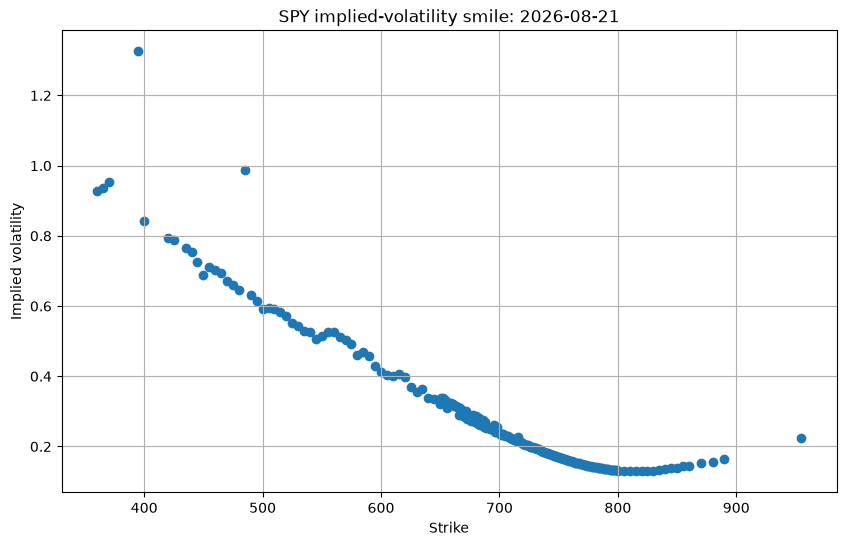

In [313]:
plt.figure(figsize=(10, 6))
plt.scatter(calls['strike'], calls['impliedVolatility'])
plt.xlabel('Strike')
plt.ylabel('Implied volatility')
plt.title(f'SPY implied-volatility smile: {expiration}')
plt.grid()
plt.show()


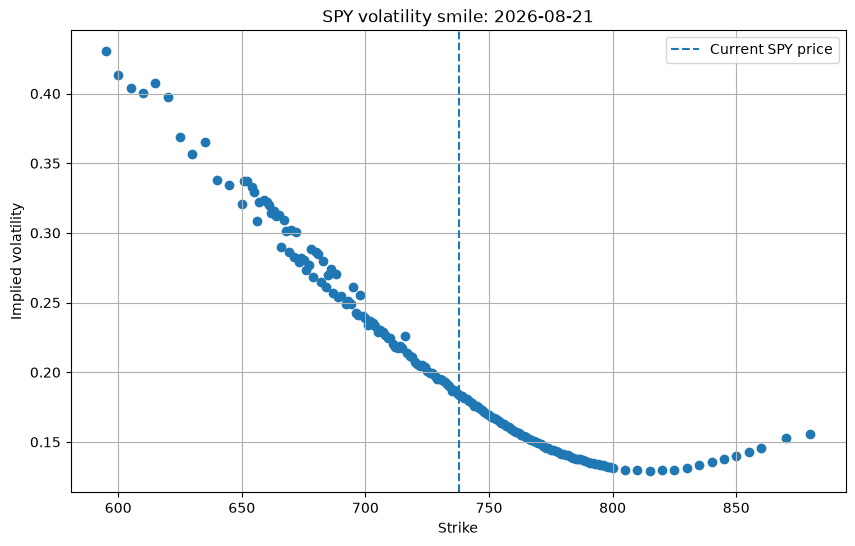

In [314]:
lower_strike = 0.8 * spot_price
upper_strike = 1.2 * spot_price
calls_near_money = calls[calls['strike'].between(lower_strike, upper_strike)].copy()
plt.figure(figsize=(10, 6))
plt.scatter(calls_near_money['strike'], calls_near_money['impliedVolatility'])
plt.axvline(spot_price, linestyle='--', label='Current SPY price')
plt.xlabel('Strike')
plt.ylabel('Implied volatility')
plt.title(f'SPY volatility smile: {expiration}')
plt.legend()
plt.grid()
plt.show()


In [315]:
today = pd.Timestamp.now().normalize()
expiration_date = pd.Timestamp(expiration)
days_to_expiration = (expiration_date - today).days
T = days_to_expiration / 365
print('Days to expiration:', days_to_expiration)
print('Time to maturity:', T)


Days to expiration: 59
Time to maturity: 0.16164383561643836


## 4. Log-moneyness

Instead of plotting volatility directly against strike, we use log-moneyness `log(K / F)`. This centers the smile around the forward price and makes smiles across different expirations easier to compare.

In [316]:
forward_price = spot_price
calls_near_money['log_moneyness'] = np.log(calls_near_money['strike'] / forward_price)


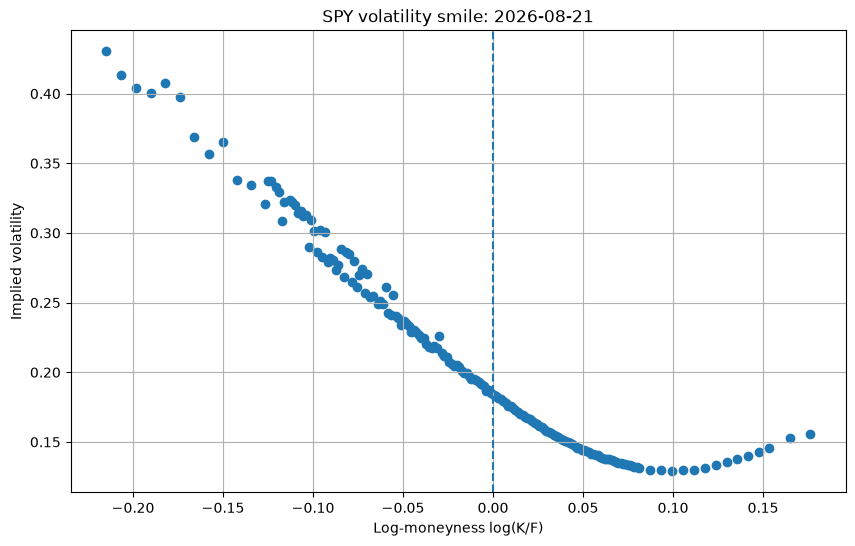

In [317]:
plt.figure(figsize=(10, 6))
plt.scatter(calls_near_money['log_moneyness'], calls_near_money['impliedVolatility'])
plt.axvline(0, linestyle='--')
plt.xlabel('Log-moneyness log(K/F)')
plt.ylabel('Implied volatility')
plt.title(f'SPY volatility smile: {expiration}')
plt.grid()
plt.show()


## 5. Black pricing and implied volatility

The notebook uses the Black forward option formula. For each market mid price, implied volatility is found by solving for the volatility that makes the model price equal to the observed option price.

In [318]:
from scipy.stats import norm
from scipy.optimize import brentq
import math


In [319]:
today = pd.Timestamp.now().normalize()
expiration_date = pd.Timestamp(expiration)
days_to_expiration = (expiration_date - today).days
T = days_to_expiration / 365
print('Days to expiration:', days_to_expiration)
print('T:', T)


Days to expiration: 59
T: 0.16164383561643836


In [320]:
r = 0.04
forward_price = spot_price * np.exp(r * T)
print('Spot:', spot_price)
print('Forward:', forward_price)


Spot: 737.77001953125
Forward: 742.5557134475227


In [321]:
def black_call_price(F, K, T, r, sigma):
    if sigma <= 0 or T <= 0:
        return np.nan
    d1 = (np.log(F / K) + 0.5 * sigma ** 2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    call_price = np.exp(-r * T) * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return call_price


In [322]:
test_price = black_call_price(F=forward_price, K=spot_price, T=T, r=r, sigma=0.2)
print('Call price with 20% volatility:', test_price)


Call price with 20% volatility: 26.037828480136085


In [323]:
def calculate_implied_volatility(market_price, F, K, T, r):

    def difference(sigma):
        model_price = black_call_price(F=F, K=K, T=T, r=r, sigma=sigma)
        return model_price - market_price
    try:
        implied_vol = brentq(difference, 0.0001, 5.0)
        return implied_vol
    except ValueError:
        return np.nan


In [324]:
atm_index = (calls['strike'] - spot_price).abs().idxmin()
test_option = calls.loc[atm_index]


In [325]:
my_iv = calculate_implied_volatility(market_price=test_option['mid_price'], F=forward_price, K=test_option['strike'], T=T, r=r)
print('My implied volatility:', my_iv)
print('Yahoo implied volatility:', test_option['impliedVolatility'])


My implied volatility: 0.16424594811395127
Yahoo implied volatility: 0.1839070867919922


In [326]:
calls['my_implied_volatility'] = calls.apply(lambda row: calculate_implied_volatility(market_price=row['mid_price'], F=forward_price, K=row['strike'], T=T, r=r), axis=1)


In [327]:
calls = calls.dropna(subset=['my_implied_volatility'])


In [328]:
calls[['strike', 'mid_price', 'impliedVolatility', 'my_implied_volatility']].head(10)


,strike,mid_price,impliedVolatility,my_implied_volatility
1,365.0,375.180,0.935914,0.599944
2,370.0,370.720,0.953736,0.752145
4,395.0,359.900,1.325107,1.285127
5,400.0,340.430,0.842043,0.544350
6,420.0,320.655,0.794924,0.545464
7,425.0,315.820,0.788698,0.569902
8,435.0,305.935,0.765383,0.558247
9,440.0,300.995,0.753909,0.552424
10,445.0,295.715,0.726809,0.453603
12,455.0,286.000,0.712100,0.503307


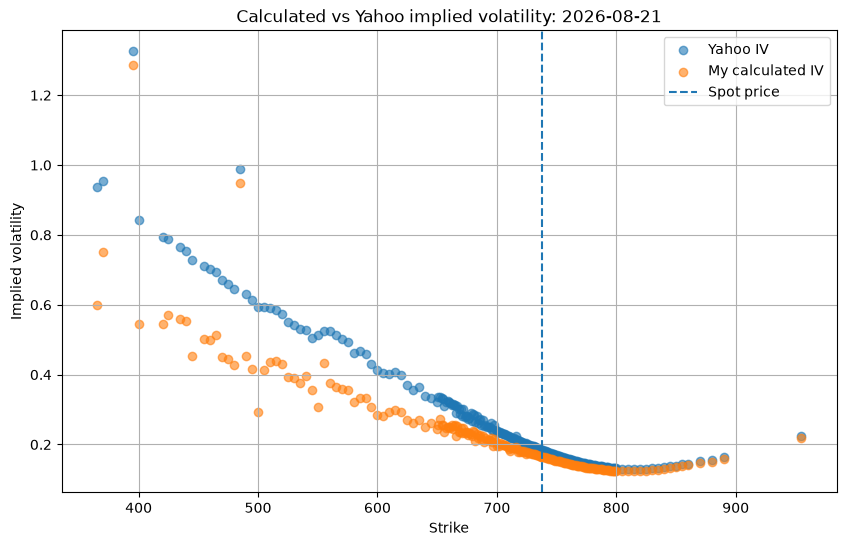

In [329]:
plt.figure(figsize=(10, 6))
plt.scatter(calls['strike'], calls['impliedVolatility'], label='Yahoo IV', alpha=0.6)
plt.scatter(calls['strike'], calls['my_implied_volatility'], label='My calculated IV', alpha=0.6)
plt.axvline(spot_price, linestyle='--', label='Spot price')
plt.xlabel('Strike')
plt.ylabel('Implied volatility')
plt.title(f'Calculated vs Yahoo implied volatility: {expiration}')
plt.legend()
plt.grid()
plt.show()


In [330]:
option_chain = ticker.option_chain(expiration)
calls = option_chain.calls.copy()
puts = option_chain.puts.copy()


In [331]:
def clean_options(options):
    options = options.copy()
    options = options[(options['bid'] > 0) & (options['ask'] > options['bid'])].copy()
    options['mid_price'] = (options['bid'] + options['ask']) / 2
    options['relative_spread'] = (options['ask'] - options['bid']) / options['mid_price']
    options = options[options['relative_spread'] < 0.3].copy()
    options = options[options['openInterest'] > 0].copy()
    return options


In [332]:
calls = clean_options(calls)
puts = clean_options(puts)


## 6. Forward price from put-call parity

A better forward estimate comes from matching calls and puts with the same strike. Put-call parity implies a forward candidate for each matched pair, and the median of the best near-the-money pairs is used as the expiration-specific forward.

In [333]:
call_put_pairs = calls[['strike', 'mid_price', 'relative_spread']].merge(puts[['strike', 'mid_price', 'relative_spread']], on='strike', suffixes=('_call', '_put'))


In [334]:
call_put_pairs.head()


,strike,mid_price_call,relative_spread_call,mid_price_put,relative_spread_put
0,360.0,380.17,0.008365,0.115,0.086957
1,365.0,375.18,0.008423,0.125,0.080000
2,370.0,370.72,0.007553,0.130,0.153846
3,395.0,359.90,0.009003,0.175,0.057143
4,400.0,340.43,0.008930,0.185,0.054054


In [335]:
call_put_pairs['forward_candidate'] = call_put_pairs['strike'] + np.exp(r * T) * (call_put_pairs['mid_price_call'] - call_put_pairs['mid_price_put'])


In [336]:
call_put_pairs[['strike', 'mid_price_call', 'mid_price_put', 'forward_candidate']].head(20)


,strike,mid_price_call,mid_price_put,forward_candidate
0,360.0,380.170,0.115,742.520303
1,365.0,375.180,0.125,742.487870
2,370.0,370.720,0.130,742.993907
3,395.0,359.900,0.175,757.058429
4,400.0,340.430,0.185,742.452068
5,420.0,320.655,0.225,742.508534
6,425.0,315.820,0.240,742.627073
7,435.0,305.935,0.265,742.652790
8,440.0,300.995,0.280,742.665648
9,445.0,295.715,0.285,742.346366


In [337]:
near_atm_pairs = call_put_pairs[call_put_pairs['strike'].between(0.9 * spot_price, 1.1 * spot_price)].copy()


In [338]:
near_atm_pairs['pair_spread'] = near_atm_pairs['relative_spread_call'] + near_atm_pairs['relative_spread_put']
best_pairs = near_atm_pairs.nsmallest(max(3, len(near_atm_pairs) // 2), 'pair_spread')
best_pairs


,strike,mid_price_call,relative_spread_call,mid_price_put,relative_spread_put,forward_candidate,pair_spread
88,690.0,59.175,0.002873,6.510,0.003072,743.006622,0.005945
143,746.0,16.995,0.002942,20.525,0.003410,742.447102,0.006353
145,748.0,15.875,0.003150,21.455,0.003263,742.383804,0.006412
140,743.0,18.805,0.002659,19.170,0.004173,742.632632,0.006832
144,747.0,16.435,0.003042,20.960,0.003817,742.445648,0.006859
...,...,...,...,...,...,...,...
75,677.0,70.715,0.005232,5.120,0.007813,743.020495,0.013045
71,673.0,73.995,0.004730,4.790,0.008351,742.653912,0.013081
130,733.0,25.150,0.008748,15.495,0.004518,742.717629,0.013265
160,763.0,8.835,0.005659,29.805,0.007717,741.893974,0.013376


In [339]:
forward_price = best_pairs['forward_candidate'].median()
print('Spot price:', spot_price)
print('Market-implied forward:', forward_price)


Spot price: 737.77001953125
Market-implied forward: 742.6819828831395


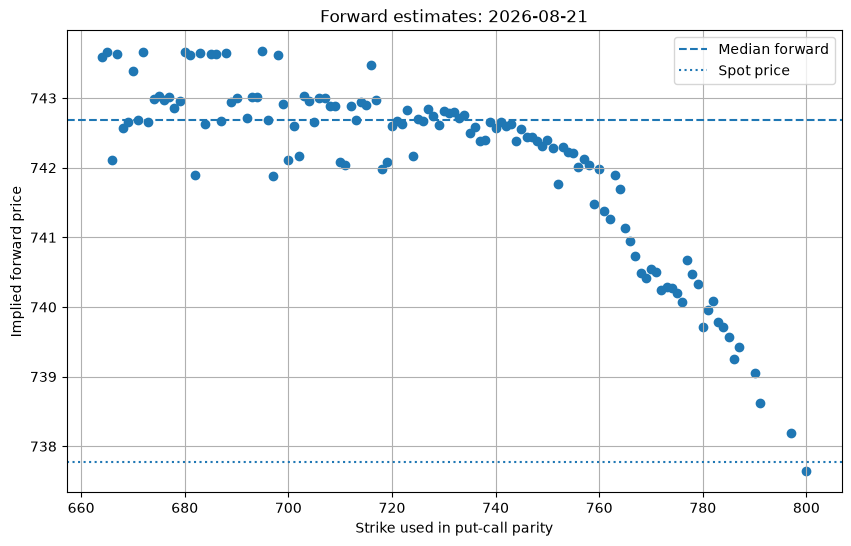

In [340]:
plt.figure(figsize=(10, 6))
plt.scatter(near_atm_pairs['strike'], near_atm_pairs['forward_candidate'])
plt.axhline(forward_price, linestyle='--', label='Median forward')
plt.axhline(spot_price, linestyle=':', label='Spot price')
plt.xlabel('Strike used in put-call parity')
plt.ylabel('Implied forward price')
plt.title(f'Forward estimates: {expiration}')
plt.legend()
plt.grid()
plt.show()


## 7. OTM puts and OTM calls

For a cleaner smile, we use out-of-the-money puts below the forward and out-of-the-money calls above the forward. These options are usually the more liquid side of the market and avoid mixing deep ITM quotes with wide spreads.

In [341]:
def black_put_price(F, K, T, r, sigma):
    if sigma <= 0 or T <= 0:
        return np.nan
    d1 = (np.log(F / K) + 0.5 * sigma ** 2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    put_price = np.exp(-r * T) * (K * norm.cdf(-d2) - F * norm.cdf(-d1))
    return put_price


In [342]:
def calculate_implied_volatility_upd(market_price, F, K, T, r, option_type):

    def difference(sigma):
        if option_type == 'call':
            model_price = black_call_price(F=F, K=K, T=T, r=r, sigma=sigma)
        elif option_type == 'put':
            model_price = black_put_price(F=F, K=K, T=T, r=r, sigma=sigma)
        else:
            raise ValueError('option_type must be call or put')
        return model_price - market_price
    try:
        return brentq(difference, 0.0001, 5.0)
    except ValueError:
        return np.nan


In [343]:
otm_puts = puts[puts['strike'] < forward_price].copy()


In [344]:
otm_calls = calls[calls['strike'] >= forward_price].copy()


In [345]:
otm_puts['my_implied_volatility'] = otm_puts.apply(lambda row: calculate_implied_volatility_upd(market_price=row['mid_price'], F=forward_price, K=row['strike'], T=T, r=r, option_type='put'), axis=1)


In [346]:
otm_puts['option_type'] = 'put'


In [347]:
otm_calls['my_implied_volatility'] = otm_calls.apply(lambda row: calculate_implied_volatility_upd(market_price=row['mid_price'], F=forward_price, K=row['strike'], T=T, r=r, option_type='call'), axis=1)


In [348]:
otm_calls['option_type'] = 'call'


In [349]:
smile_data = pd.concat([otm_puts, otm_calls], ignore_index=True)


In [350]:
smile_data = smile_data.dropna(subset=['my_implied_volatility'])


In [351]:
smile_data = smile_data[smile_data['my_implied_volatility'].between(0.01, 2.0)].copy()


In [352]:
smile_data = smile_data.sort_values('strike')


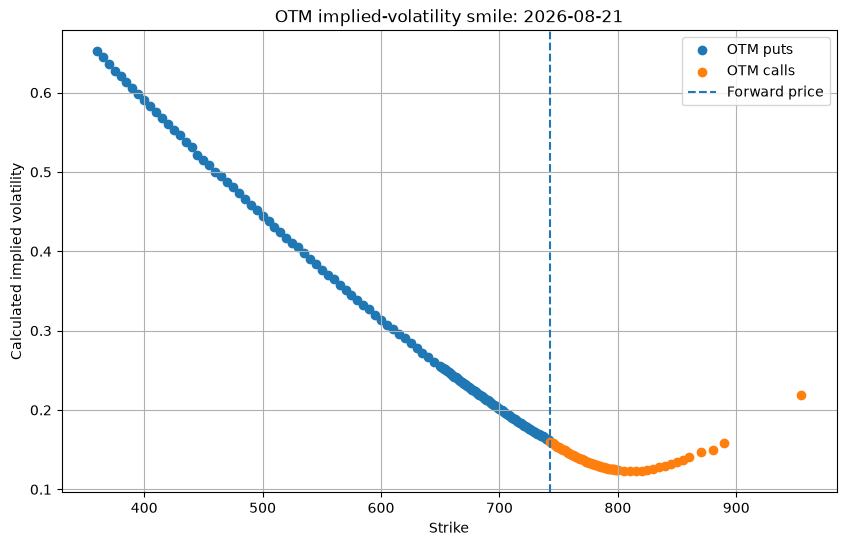

In [353]:
plt.figure(figsize=(10, 6))
put_data = smile_data[smile_data['option_type'] == 'put']
call_data = smile_data[smile_data['option_type'] == 'call']
plt.scatter(put_data['strike'], put_data['my_implied_volatility'], label='OTM puts')
plt.scatter(call_data['strike'], call_data['my_implied_volatility'], label='OTM calls')
plt.axvline(forward_price, linestyle='--', label='Forward price')
plt.xlabel('Strike')
plt.ylabel('Calculated implied volatility')
plt.title(f'OTM implied-volatility smile: {expiration}')
plt.legend()
plt.grid()
plt.show()


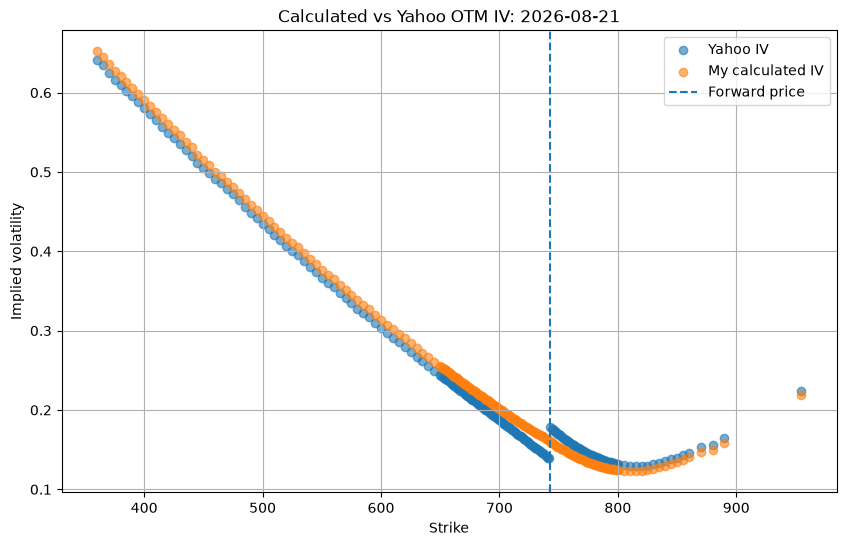

In [354]:
plt.figure(figsize=(10, 6))
plt.scatter(smile_data['strike'], smile_data['impliedVolatility'], label='Yahoo IV', alpha=0.6)
plt.scatter(smile_data['strike'], smile_data['my_implied_volatility'], label='My calculated IV', alpha=0.6)
plt.axvline(forward_price, linestyle='--', label='Forward price')
plt.xlabel('Strike')
plt.ylabel('Implied volatility')
plt.title(f'Calculated vs Yahoo OTM IV: {expiration}')
plt.legend()
plt.grid()
plt.show()


In [355]:
def estimate_forward(calls, puts, spot_price, T, r):
    call_put_pairs = calls[['strike', 'mid_price', 'relative_spread']].merge(puts[['strike', 'mid_price', 'relative_spread']], on='strike', suffixes=('_call', '_put'))
    call_put_pairs['forward_candidate'] = call_put_pairs['strike'] + np.exp(r * T) * (call_put_pairs['mid_price_call'] - call_put_pairs['mid_price_put'])
    near_atm_pairs = call_put_pairs[call_put_pairs['strike'].between(0.9 * spot_price, 1.1 * spot_price)].copy()
    near_atm_pairs['pair_spread'] = near_atm_pairs['relative_spread_call'] + near_atm_pairs['relative_spread_put']
    if len(near_atm_pairs) < 3:
        return np.nan
    best_pairs = near_atm_pairs.nsmallest(max(3, len(near_atm_pairs) // 2), 'pair_spread')
    forward_price = best_pairs['forward_candidate'].median()
    return forward_price


## 8. Building smiles across expirations

The single-expiration logic is wrapped into a function and repeated across many expirations. Each expiration contributes one smile, and all smiles are concatenated into `surface_data`. This is the dataset used for the volatility surface.

In [356]:
selected_expirations = expirations[:30]
print('Selected expirations:', len(selected_expirations))


Selected expirations: 30


In [357]:
def build_smile_for_expiration(expiration, spot_price, r):
    expiration_date = pd.Timestamp(expiration)
    today = pd.Timestamp.now().normalize()
    T = (expiration_date - today).days / 365
    if T <= 0:
        return pd.DataFrame()
    option_chain = ticker.option_chain(expiration)
    calls = clean_options(option_chain.calls)
    puts = clean_options(option_chain.puts)
    forward_price = estimate_forward(calls=calls, puts=puts, spot_price=spot_price, T=T, r=r)
    if np.isnan(forward_price):
        return pd.DataFrame()
    otm_puts = puts[puts['strike'] < forward_price].copy()
    otm_calls = calls[calls['strike'] >= forward_price].copy()
    otm_puts['my_implied_volatility'] = otm_puts.apply(lambda row: calculate_implied_volatility_upd(market_price=row['mid_price'], F=forward_price, K=row['strike'], T=T, r=r, option_type='put'), axis=1)
    otm_calls['my_implied_volatility'] = otm_calls.apply(lambda row: calculate_implied_volatility_upd(market_price=row['mid_price'], F=forward_price, K=row['strike'], T=T, r=r, option_type='call'), axis=1)
    otm_puts['option_type'] = 'put'
    otm_calls['option_type'] = 'call'
    smile = pd.concat([otm_puts, otm_calls], ignore_index=True)
    smile = smile.dropna(subset=['my_implied_volatility'])
    smile = smile[smile['my_implied_volatility'].between(0.01, 2.0)].copy()
    smile['expiration'] = expiration
    smile['T'] = T
    smile['forward'] = forward_price
    smile['log_moneyness'] = np.log(smile['strike'] / forward_price)
    smile['total_variance'] = smile['my_implied_volatility'] ** 2 * T
    smile = smile[smile['log_moneyness'].between(-0.35, 0.35)].copy()
    return smile.sort_values('strike')


In [358]:
all_smiles = []
for expiration in selected_expirations:
    print('Processing:', expiration)
    try:
        smile = build_smile_for_expiration(expiration=expiration, spot_price=spot_price, r=r)
    except Exception as error:
        print(f'Skipped {expiration}: {error}')
        continue
    if smile.empty:
        print(f'Skipped {expiration}: no usable quotes')
        continue
    all_smiles.append(smile)
    print(f'Added {len(smile)} quotes, forward={smile['forward'].iloc[0]:.2f}')
if not all_smiles:
    raise RuntimeError('No usable smiles were built from the selected expirations')
surface_data = pd.concat(all_smiles, ignore_index=True)
surface_data = surface_data.sort_values(['T', 'strike', 'option_type']).reset_index(drop=True)


Processing: 2026-06-23
Skipped 2026-06-23: no usable quotes
Processing: 2026-06-24
Added 55 quotes, forward=737.46
Processing: 2026-06-25
Added 66 quotes, forward=737.51
Processing: 2026-06-26
Added 78 quotes, forward=737.82
Processing: 2026-06-29
Added 86 quotes, forward=737.94
Processing: 2026-06-30
Added 185 quotes, forward=738.04
Processing: 2026-07-01
Added 87 quotes, forward=738.25
Processing: 2026-07-02
Added 150 quotes, forward=738.58
Processing: 2026-07-10
Added 182 quotes, forward=739.16
Processing: 2026-07-17
Added 180 quotes, forward=739.85
Processing: 2026-07-24
Added 181 quotes, forward=740.34
Processing: 2026-07-31
Added 209 quotes, forward=741.05
Processing: 2026-08-21
Added 192 quotes, forward=742.79
Processing: 2026-08-31
Added 216 quotes, forward=743.47
Processing: 2026-09-18
Added 268 quotes, forward=744.61
Processing: 2026-09-30
Added 154 quotes, forward=744.76
Processing: 2026-10-16
Added 89 quotes, forward=745.78
Processing: 2026-10-30
Added 160 quotes, forward=7

## 9. Surface dataset checks

Before plotting or pricing, we check how many expirations and quotes survived the filters. This is important because a surface built from too few maturities or too few strikes can look misleading.

In [359]:
summary = surface_data.groupby('expiration').agg(T=('T', 'first'), forward=('forward', 'first'), quotes=('strike', 'size'), min_strike=('strike', 'min'), max_strike=('strike', 'max')).reset_index()
print('Number of expirations:', surface_data['expiration'].nunique())
print('Total quotes:', len(surface_data))
summary.head(30)


Number of expirations: 29
Total quotes: 3978


,expiration,T,forward,quotes,min_strike,max_strike
0,2026-06-24,0.002740,737.455707,55,700.0,754.0
1,2026-06-25,0.005479,737.507392,66,670.0,760.0
2,2026-06-26,0.008219,737.824614,78,635.0,764.0
3,2026-06-29,0.016438,737.938904,86,610.0,768.0
4,2026-06-30,0.019178,738.037881,185,587.0,771.0
5,2026-07-01,0.021918,738.252180,87,600.0,775.0
6,2026-07-02,0.024658,738.575496,150,545.0,778.0
7,2026-07-10,0.046575,739.161752,182,525.0,800.0
8,2026-07-17,0.065753,739.846624,180,525.0,820.0
9,2026-07-24,0.084932,740.336228,181,525.0,830.0


In [360]:
surface_data[['expiration', 'option_type', 'strike', 'T', 'forward', 'log_moneyness', 'my_implied_volatility', 'total_variance']].head(20)


,expiration,option_type,strike,T,forward,log_moneyness,my_implied_volatility,total_variance
0,2026-06-24,put,700.0,0.00274,737.455707,-0.052126,0.405493,0.000450
1,2026-06-24,put,701.0,0.00274,737.455707,-0.050698,0.395646,0.000429
2,2026-06-24,put,702.0,0.00274,737.455707,-0.049273,0.385788,0.000408
3,2026-06-24,put,703.0,0.00274,737.455707,-0.047849,0.375918,0.000387
4,2026-06-24,put,704.0,0.00274,737.455707,-0.046428,0.366036,0.000367
5,2026-06-24,put,705.0,0.00274,737.455707,-0.045008,0.367336,0.000370
6,2026-06-24,put,706.0,0.00274,737.455707,-0.043591,0.346230,0.000328
7,2026-06-24,put,707.0,0.00274,737.455707,-0.042175,0.347001,0.000330
8,2026-06-24,put,708.0,0.00274,737.455707,-0.040762,0.336806,0.000311
9,2026-06-24,put,709.0,0.00274,737.455707,-0.039351,0.326592,0.000292


## 10. Smiles across maturities

This plot shows all extracted smiles in log-moneyness space. It is a useful diagnostic before building the 3D surface: each color should represent a different expiration.

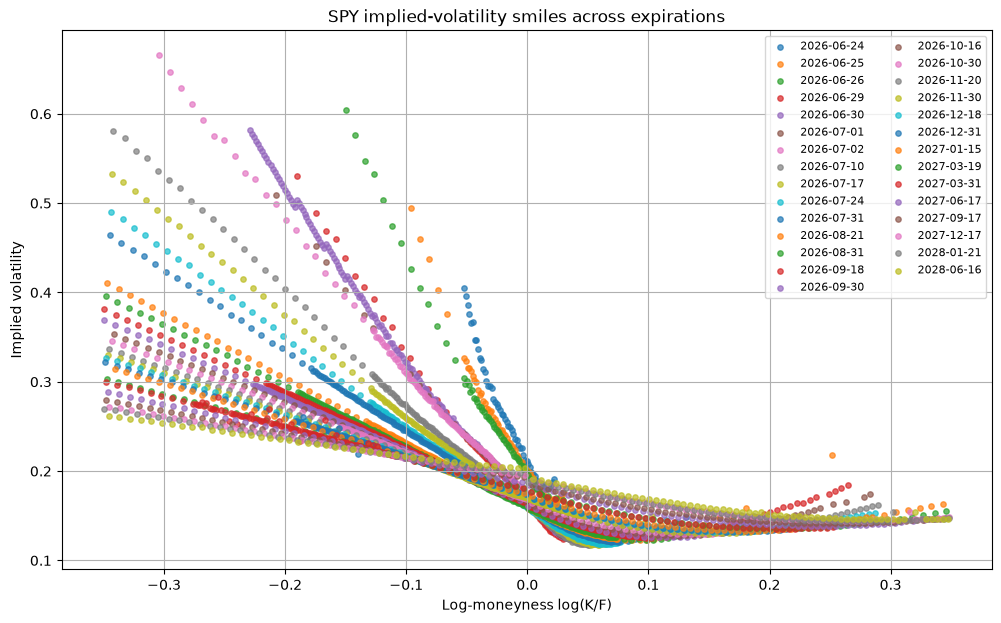

In [361]:
plt.figure(figsize=(12, 7))
for expiration, data in surface_data.groupby('expiration'):
    plt.scatter(data['log_moneyness'], data['my_implied_volatility'], label=expiration, s=15, alpha=0.7)
plt.xlabel('Log-moneyness log(K/F)')
plt.ylabel('Implied volatility')
plt.title('SPY implied-volatility smiles across expirations')
plt.legend(fontsize=8, ncol=2)
plt.grid()
plt.show()


## 11. 3D implied-volatility surface

The 3D plot interpolates total variance across log-moneyness and maturity, then converts it back to implied volatility. Interpolating total variance is more natural than interpolating volatility directly because total variance scales with time.

In [362]:
import plotly.graph_objects as go
from scipy.interpolate import griddata
plot_data['total_variance'] = plot_data['my_implied_volatility'] ** 2 * plot_data['T']
k_min = plot_data['log_moneyness'].quantile(0.02)
k_max = plot_data['log_moneyness'].quantile(0.98)
t_min = plot_data['T'].min()
t_max = plot_data['T'].max()
k_grid = np.linspace(k_min, k_max, 80)
t_grid = np.linspace(t_min, t_max, 60)
K_GRID, T_GRID = np.meshgrid(k_grid, t_grid)
surface_points = plot_data[['log_moneyness', 'T']].to_numpy()
surface_values = plot_data['total_variance'].to_numpy()
W_GRID = griddata(points=surface_points, values=surface_values, xi=(K_GRID, T_GRID), method='linear')
IV_GRID = np.sqrt(W_GRID / T_GRID)
fig = go.Figure()
surface_trace = go.Surface(x=K_GRID, y=T_GRID * 365, z=IV_GRID, colorscale='Viridis', opacity=0.85, name='Interpolated IV surface', showscale=True, colorbar={'title': 'IV'})
fig.add_trace(surface_trace)
quote_marker = {'size': 2, 'color': plot_data['my_implied_volatility'], 'colorscale': 'Viridis', 'opacity': 0.45}
quote_trace = go.Scatter3d(x=plot_data['log_moneyness'], y=plot_data['T'] * 365, z=plot_data['my_implied_volatility'], mode='markers', marker=quote_marker, text=plot_data['expiration'], name='Option quotes')
fig.add_trace(quote_trace)
scene_labels = {'xaxis_title': 'Log-moneyness log(K/F)', 'yaxis_title': 'Days to expiration', 'zaxis_title': 'Implied volatility'}
fig.update_layout(title='SPY implied-volatility surface', scene=scene_labels, height=750, margin={'l': 0, 'r': 0, 'b': 0, 't': 50})
fig.show()


## 12. Reading IV from the surface

After the grid is built, `get_surface_iv` interpolates an implied volatility for any target log-moneyness and maturity inside the grid. This turns the visual surface into something usable for pricing.

In [363]:
def get_surface_iv(log_moneyness, T):
    iv = griddata(points=np.column_stack([K_GRID.ravel(), T_GRID.ravel()]), values=IV_GRID.ravel(), xi=np.array([[log_moneyness, T]]), method='linear')[0]
    return iv


In [364]:
test_k = 0.0
test_T = 90 / 365
test_iv = get_surface_iv(test_k, test_T)
print('Surface IV:', test_iv)


Surface IV: 0.15208041394428137


## 13. Pricing a custom digital call

The target OTC payoff is a cash-or-nothing digital call. We choose a strike and maturity, read the matching implied volatility from the surface, then price the digital option under the Black formula. A flat-volatility price is also computed for comparison.

In [365]:
target_days = 90
target_T = target_days / 365
target_K = 0.95 * spot_price


In [366]:
forward_curve = surface_data.groupby('T')['forward'].median().reset_index().sort_values('T')
target_forward = np.interp(target_T, forward_curve['T'], forward_curve['forward'])
print('Target forward:', target_forward)


Target forward: 744.6470154446694


In [367]:
target_k = np.log(target_K / target_forward)
print('Target log-moneyness:', target_k)


Target log-moneyness: -0.06057144633053061


In [368]:
target_iv = get_surface_iv(target_k, target_T)
print('Target IV:', target_iv)


Target IV: 0.18719812280896772


In [369]:
def digital_call_price(F, K, T, r, sigma):
    d2 = (np.log(F / K) - 0.5 * sigma ** 2 * T) / (sigma * np.sqrt(T))
    price = np.exp(-r * T) * norm.cdf(d2)
    return price


In [370]:
digital_price = digital_call_price(F=target_forward, K=target_K, T=target_T, r=r, sigma=target_iv)
print('Digital call price:', digital_price)


Digital call price: 0.7203166877686437


In [371]:
notional = 10000
print('Contract value:', digital_price * notional)


Contract value: 7203.166877686436


In [372]:
atm_iv = get_surface_iv(log_moneyness=0.0, T=target_T)


In [373]:
flat_price = digital_call_price(F=target_forward, K=target_K, T=target_T, r=r, sigma=atm_iv)
print('Surface price:', digital_price)
print('Flat-vol price:', flat_price)
print('Difference:', digital_price - flat_price)


Surface price: 0.7203166877686437
Flat-vol price: 0.7700308540719947
Difference: -0.049714166303351015
